# Step 1: Setup & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load Excel file
file_path = "corep_data.xlsx"

# Load all sheets
patient = pd.read_excel(file_path, sheet_name="Patients")
nursing = pd.read_excel(file_path, sheet_name="Nursing_Assessments")
consultations = pd.read_excel(file_path, sheet_name="Consultations")
lab_tests = pd.read_excel(file_path, sheet_name="Lab_Tests")
optical = pd.read_excel(file_path, sheet_name="Optical_Assessments")
pharmacy = pd.read_excel(file_path, sheet_name="Pharmacy_Orders")
drugs = pd.read_excel(file_path, sheet_name="Drugs")

# Quick overview
sheets = {
    "patient": patient, "nursing": nursing, "consultations": consultations,
    "lab_tests": lab_tests, "optical": optical, "pharmacy": pharmacy, "drugs": drugs
}
for name, df in sheets.items():
    print(f"{name:15s} -> shape: {df.shape}")

patient         -> shape: (189, 16)
nursing         -> shape: (182, 17)
consultations   -> shape: (122, 17)
lab_tests       -> shape: (22, 17)
optical         -> shape: (13, 22)
pharmacy        -> shape: (577, 16)
drugs           -> shape: (61, 8)


# Step 2: Data Cleaning Utility

In [7]:
def clean_df(df, date_cols=None):
    """Clean dataframe: strip columns, convert dates, drop empty rows."""
    df = df.copy()
    df.columns = df.columns.str.strip()
    if date_cols:
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
    df = df.dropna(how='all')
    return df

# Clean each sheet
patient = clean_df(patient, ['Created At', 'Updated At', 'Date Of Birth'])
nursing = clean_df(nursing, ['Created At', 'Updated At', 'Completed At'])
consultations = clean_df(consultations, ['Created At', 'Updated At', 'Completed At'])
lab_tests = clean_df(lab_tests, ['Created At', 'Updated At', 'Completed At', 'Viewed At'])
optical = clean_df(optical, ['Created At', 'Updated At', 'Completed At',
                              'Viewed At', 'Viewed By Physician At'])
pharmacy = clean_df(pharmacy, ['Created At', 'Updated At', 'Dispensed At'])
drugs = clean_df(drugs, ['Created At', 'Updated At'])

# Step 3: Data Quality Report

In [8]:
def data_quality_report(df, name):
    print(f"\n===== {name} =====")
    print(f"Rows: {len(df)} | Columns: {len(df.columns)}")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
    print(report[report['Missing'] > 0].sort_values('Missing %', ascending=False))
    print(f"Duplicates: {df.duplicated().sum()}")

for name, df in sheets.items():
    data_quality_report(df, name)


===== patient =====
Rows: 189 | Columns: 16
               Missing  Missing %
Created By Id      188      99.47
Updated By Id      188      99.47
Middle Name          7       3.70
Duplicates: 0

===== nursing =====
Rows: 182 | Columns: 17
                   Missing  Missing %
Updated By Id          182     100.00
Respiratory Rate       182     100.00
Oxygen Saturation      182     100.00
Notes                  182     100.00
Biohazard Risk         179      98.35
Temperature             86      47.25
Duplicates: 0

===== consultations =====
Rows: 122 | Columns: 17
                       Missing  Missing %
Updated By Id              122     100.00
Referral Notes             121      99.18
Nursing Assessment Id       15      12.30
Duplicates: 0

===== lab_tests =====
Rows: 22 | Columns: 17
                    Missing  Missing %
Updated By Id            22      100.0
Other Tests              22      100.0
Notes                    22      100.0
Random Blood Sugar       11       50.0
Comple

# Step 4: Patient Demographics Analysis

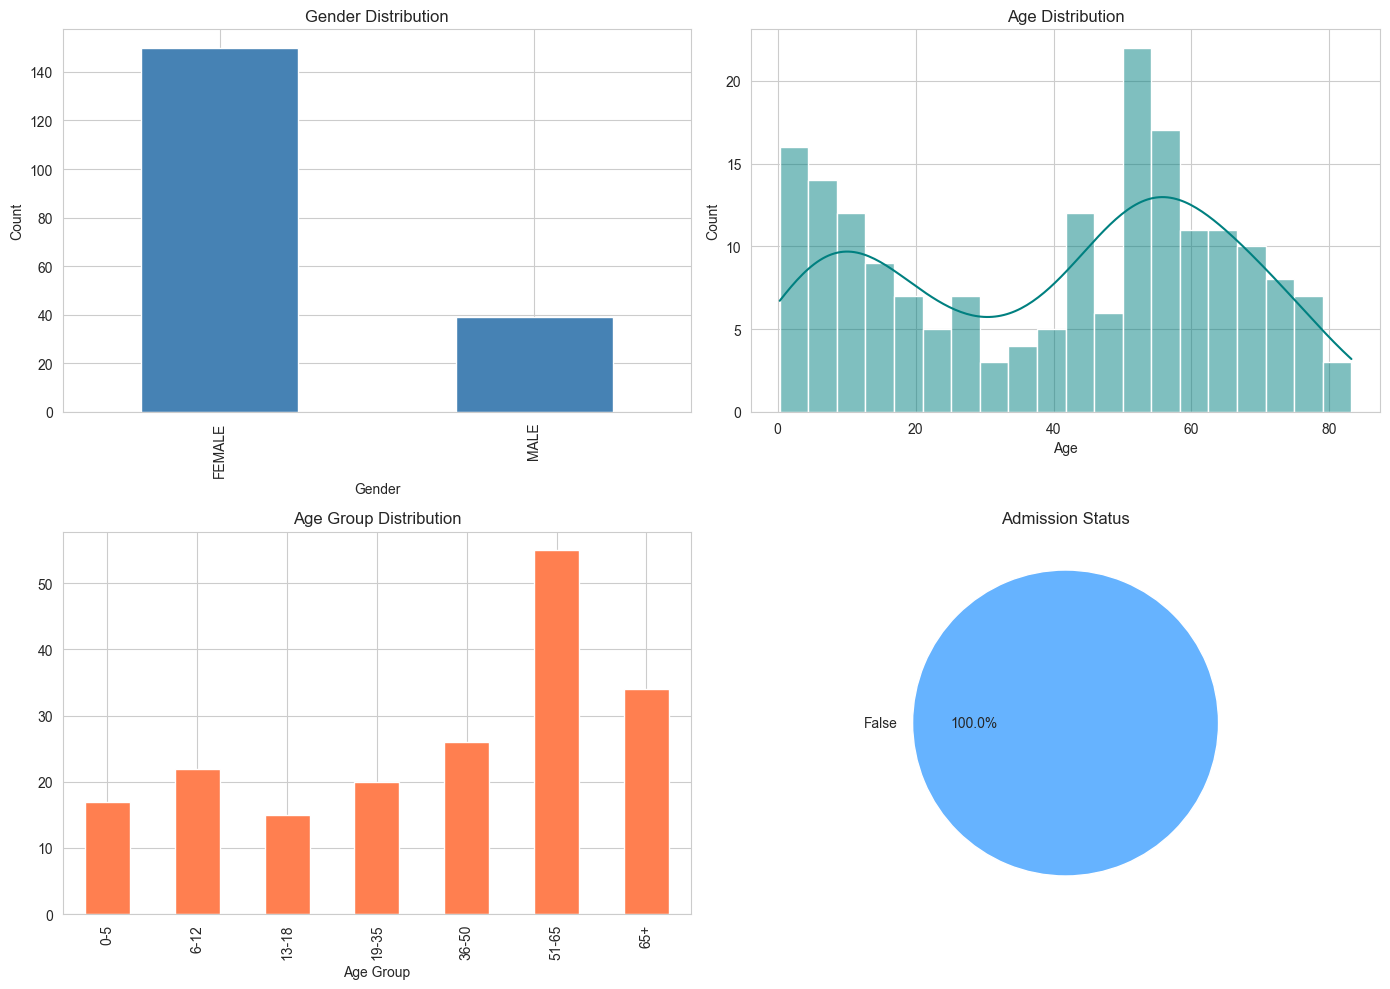

In [9]:
# Age calculation
today = pd.Timestamp.today()
patient['Age'] = ((today - patient['Date Of Birth']).dt.days / 365.25).round(1)

# Age groups
bins = [0, 5, 12, 18, 35, 50, 65, 120]
labels = ['0-5', '6-12', '13-18', '19-35', '36-50', '51-65', '65+']
patient['Age Group'] = pd.cut(patient['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender distribution
patient['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Gender Distribution')
axes[0,0].set_ylabel('Count')

# Age distribution
sns.histplot(patient['Age'].dropna(), bins=20, kde=True, ax=axes[0,1], color='teal')
axes[0,1].set_title('Age Distribution')

# Age groups
patient['Age Group'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Age Group Distribution')

# Admission status
patient['Is Admitted'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                            ax=axes[1,1], colors=['#66b3ff','#ff9999'])
axes[1,1].set_title('Admission Status')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('patient_demographics.png', dpi=100, bbox_inches='tight')
plt.show()

# Step 5: Patient Registration Trend

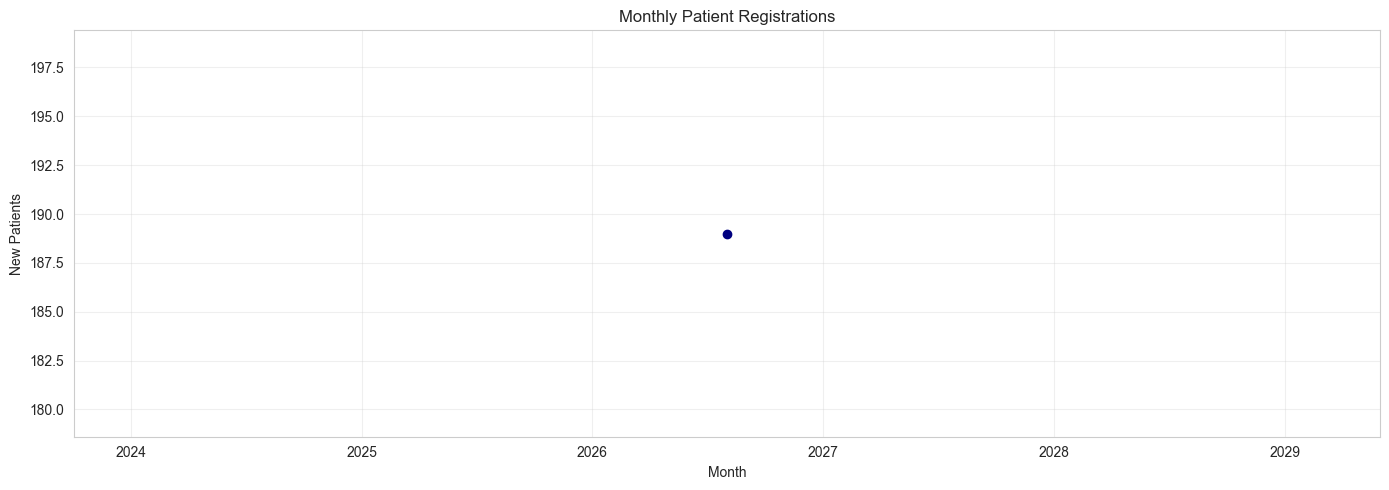

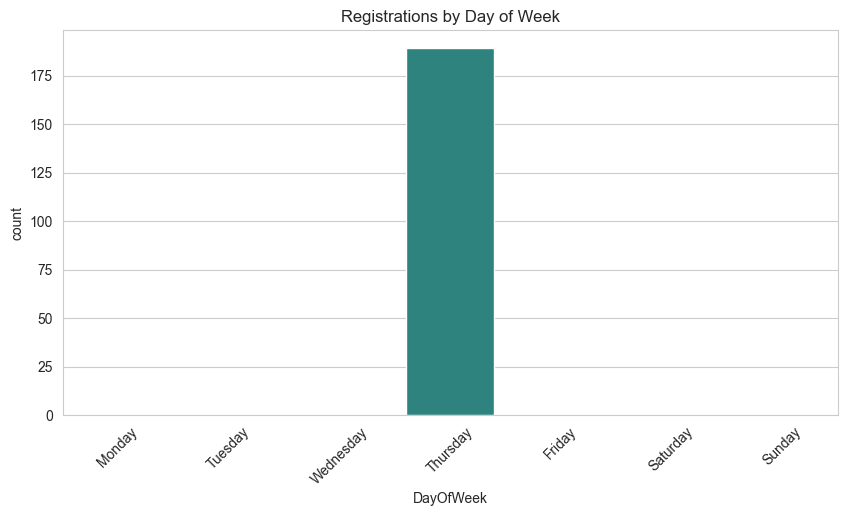

In [11]:
patient['Created Month'] = patient['Created At'].dt.to_period('M')
monthly = patient.groupby('Created Month').size()

plt.figure(figsize=(14, 5))
monthly.plot(kind='line', marker='o', color='navy')
plt.title('Monthly Patient Registrations')
plt.xlabel('Month')
plt.ylabel('New Patients')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Day of week pattern
patient['DayOfWeek'] = patient['Created At'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(data=patient, x='DayOfWeek', order=order, palette='viridis')
plt.title('Registrations by Day of Week')
plt.xticks(rotation=45)
plt.show()

# Step 6: Vital Signs Analysis (Nursing)

       Blood Pressure Systolic  Blood Pressure Diastolic  Pulse Rate  \
count                   182.00                    182.00      182.00   
mean                    107.01                     64.19       63.98   
std                      60.45                     36.33       36.03   
min                       0.00                      0.00        0.00   
25%                     103.25                     64.25       62.00   
50%                     124.00                     74.00       76.00   
75%                     145.00                     85.00       87.00   
max                     220.00                    185.00      124.00   

       Temperature  Respiratory Rate  Oxygen Saturation  
count        96.00               0.0                0.0  
mean         36.34               NaN                NaN  
std           0.29               NaN                NaN  
min          35.30               NaN                NaN  
25%          36.20               NaN                NaN  
50%

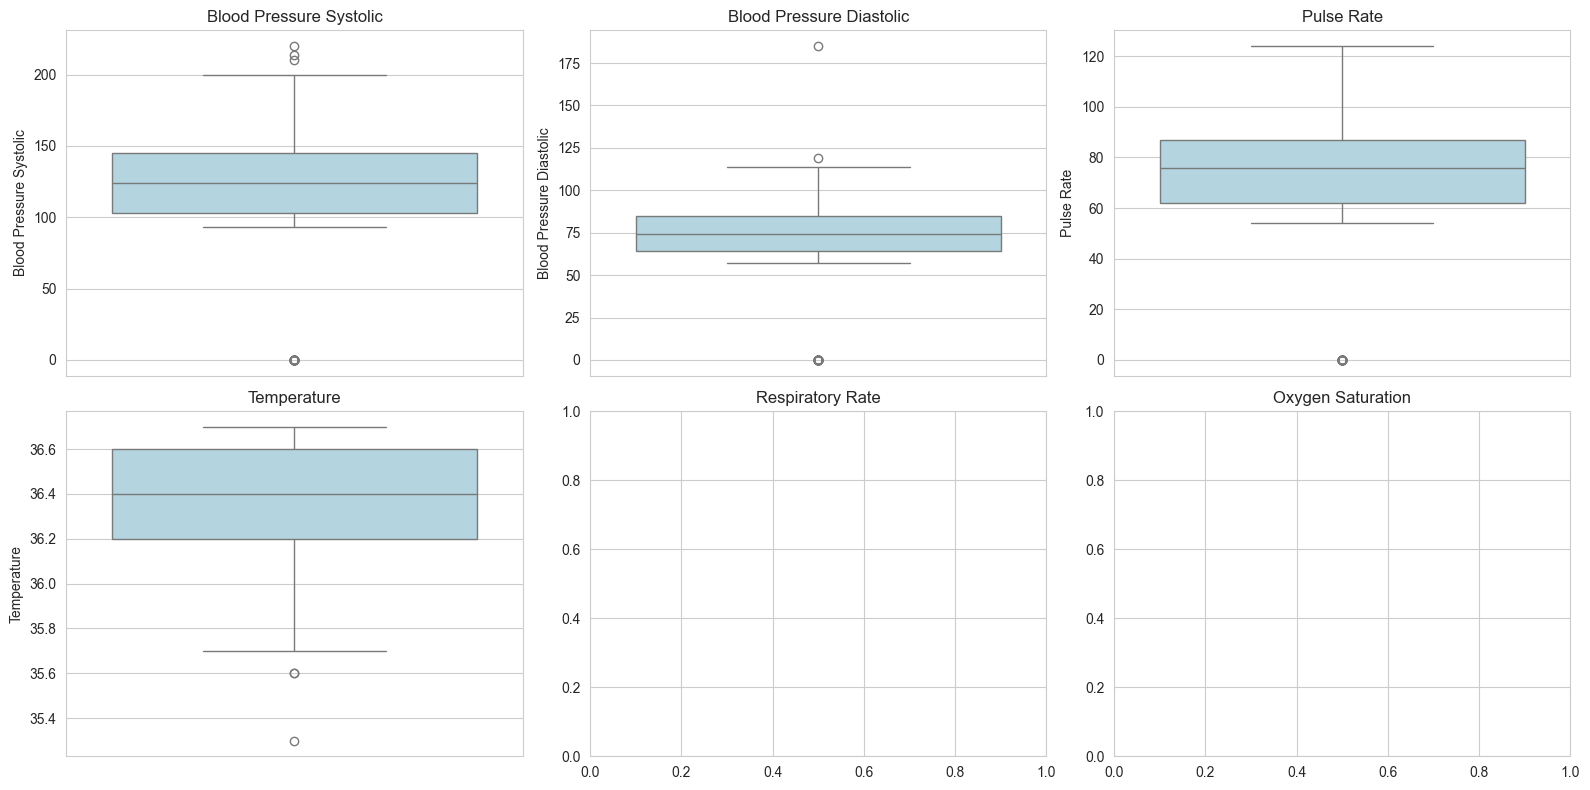

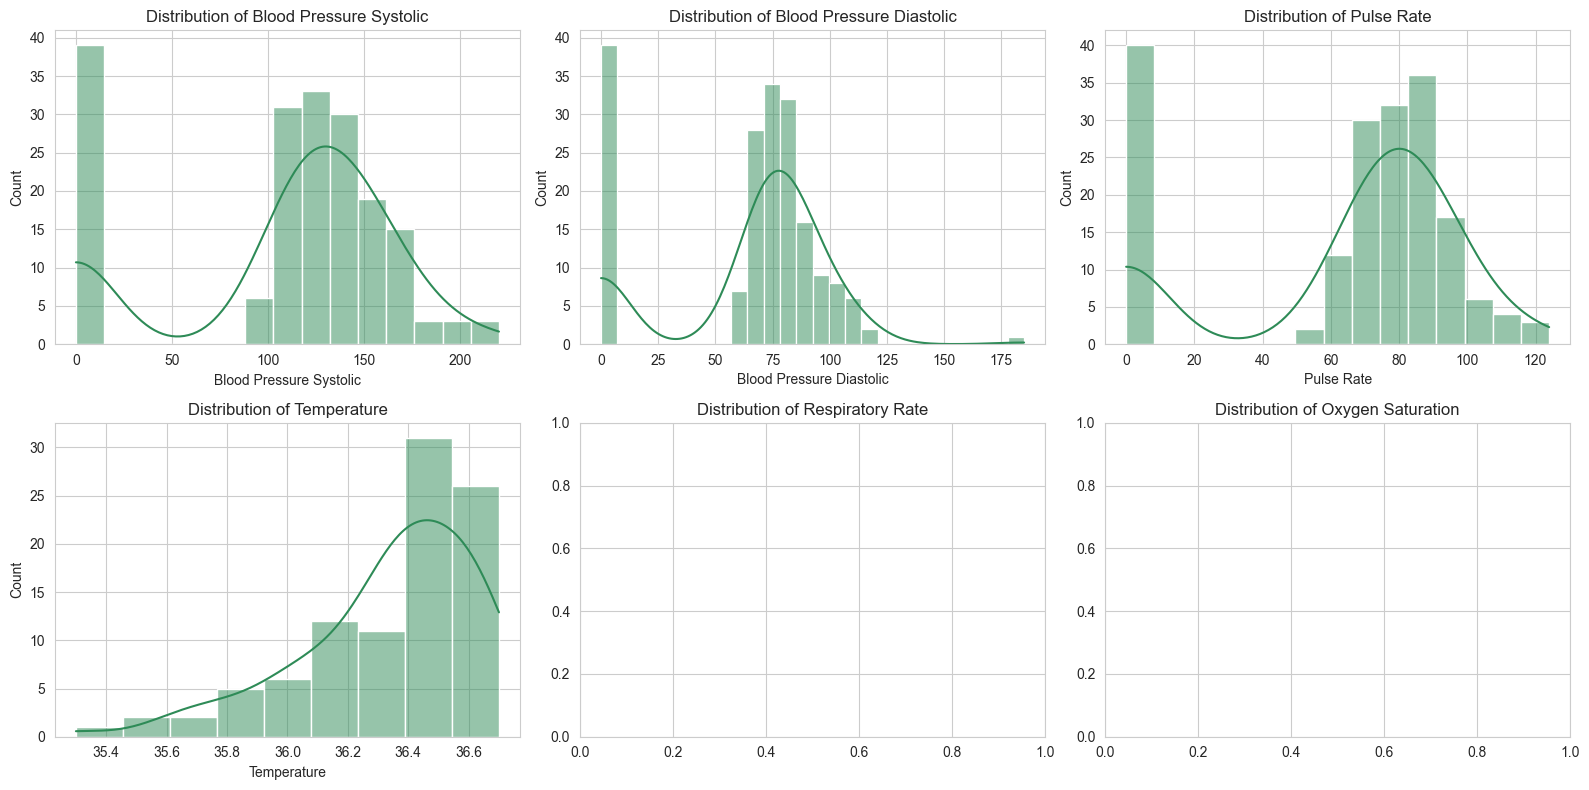

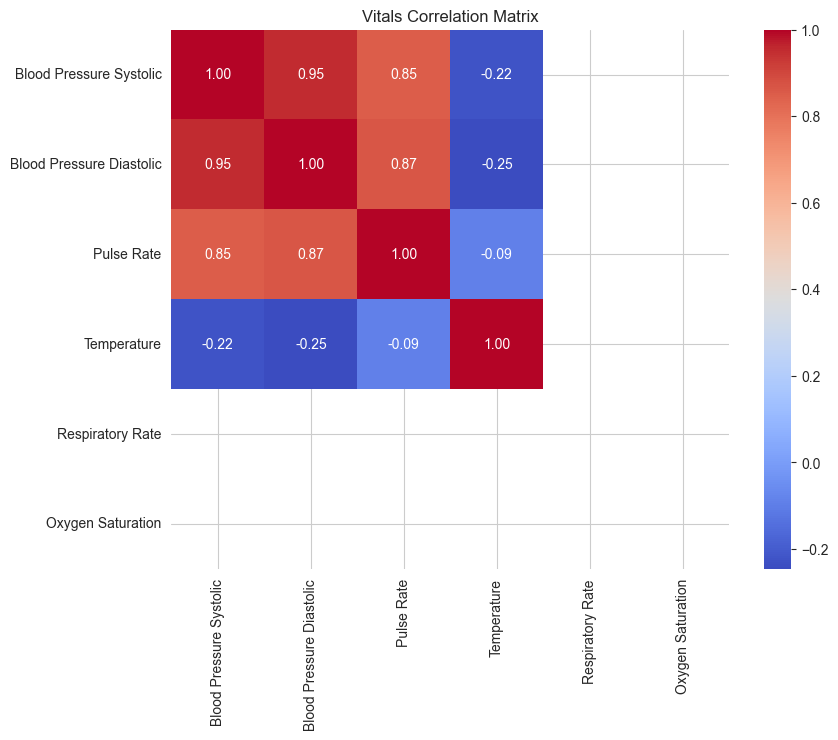

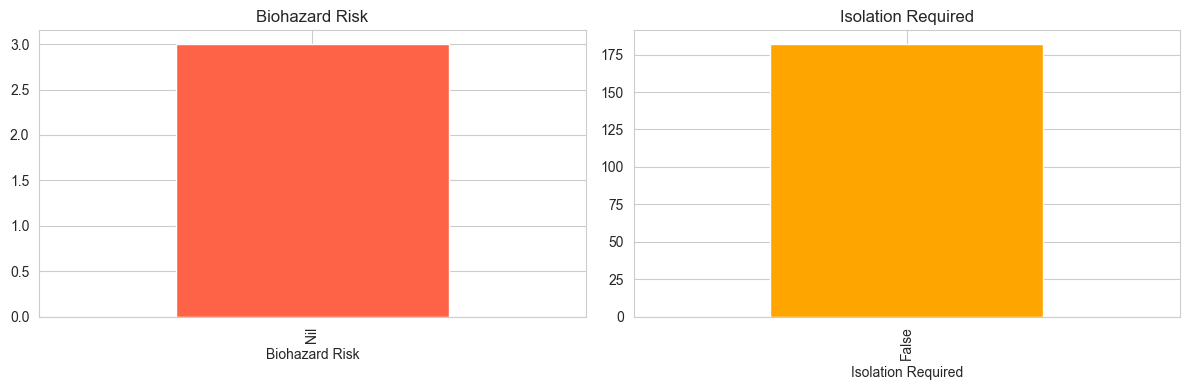

In [12]:
vitals = ['Blood Pressure Systolic', 'Blood Pressure Diastolic',
          'Pulse Rate', 'Temperature', 'Respiratory Rate', 'Oxygen Saturation']

# Summary statistics
print(nursing[vitals].describe().round(2))

# Box plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), vitals):
    sns.boxplot(y=nursing[col].dropna(), ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), vitals):
    sns.histplot(nursing[col].dropna(), kde=True, ax=ax, color='seagreen')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(nursing[vitals].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Vitals Correlation Matrix')
plt.show()

# Biohazard / Isolation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nursing['Biohazard Risk'].value_counts().plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Biohazard Risk')
nursing['Isolation Required'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Isolation Required')
plt.tight_layout()
plt.show()

# Step 7: Consultations Analysis

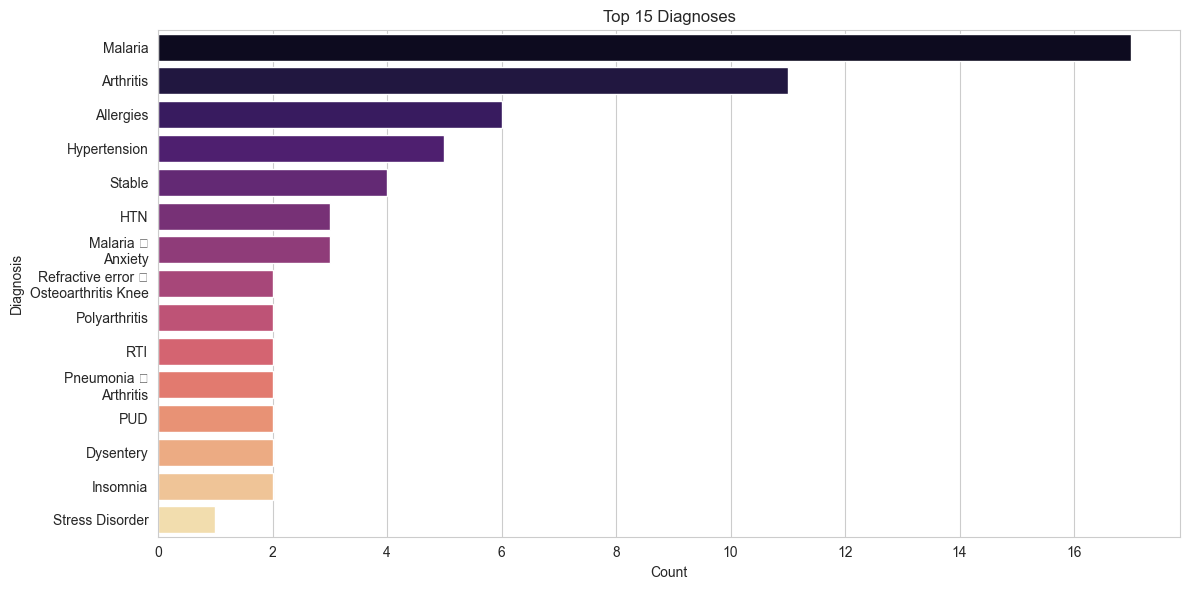

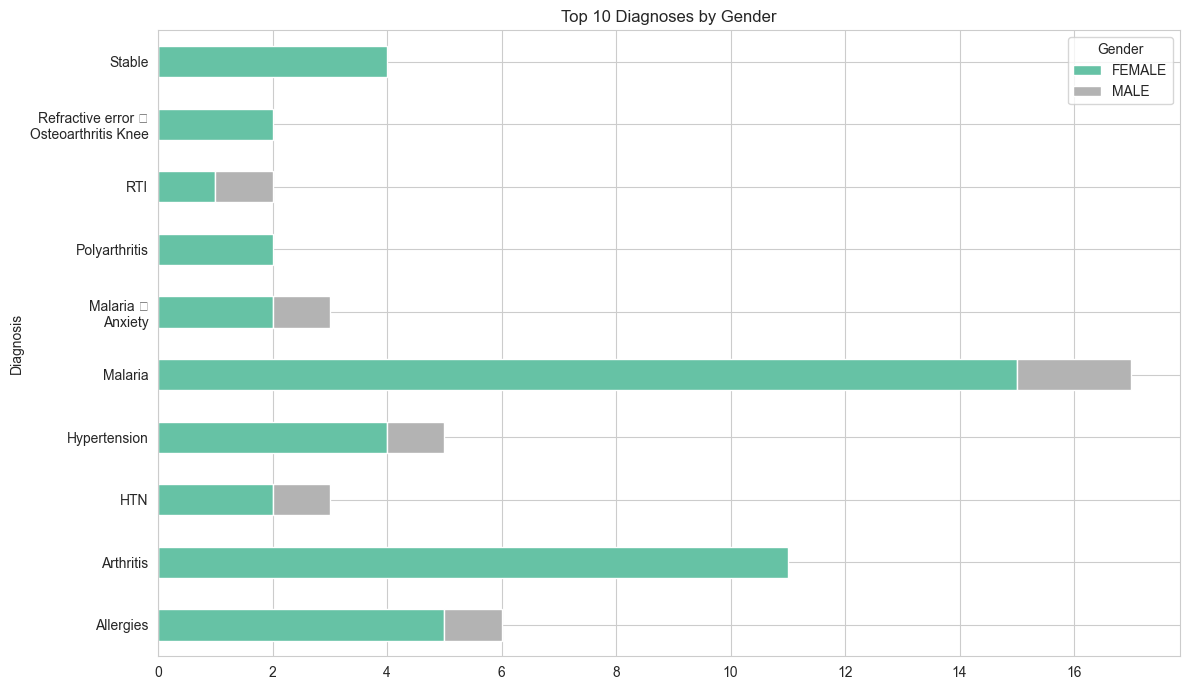

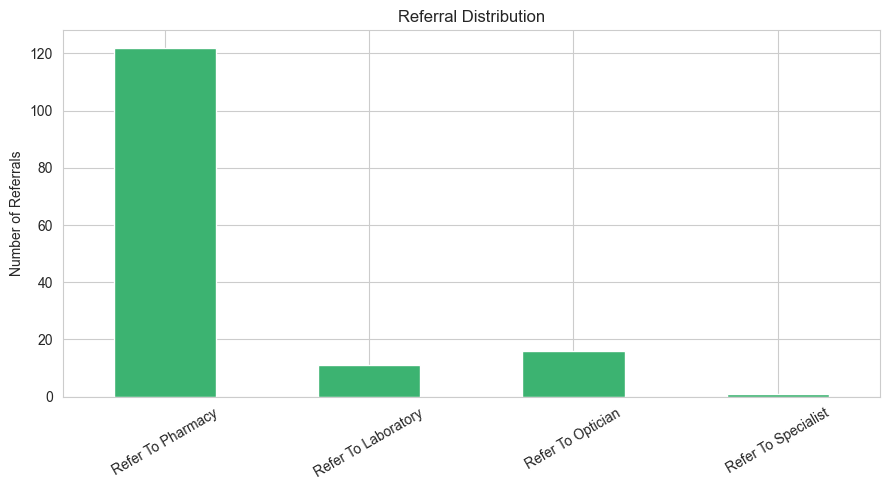

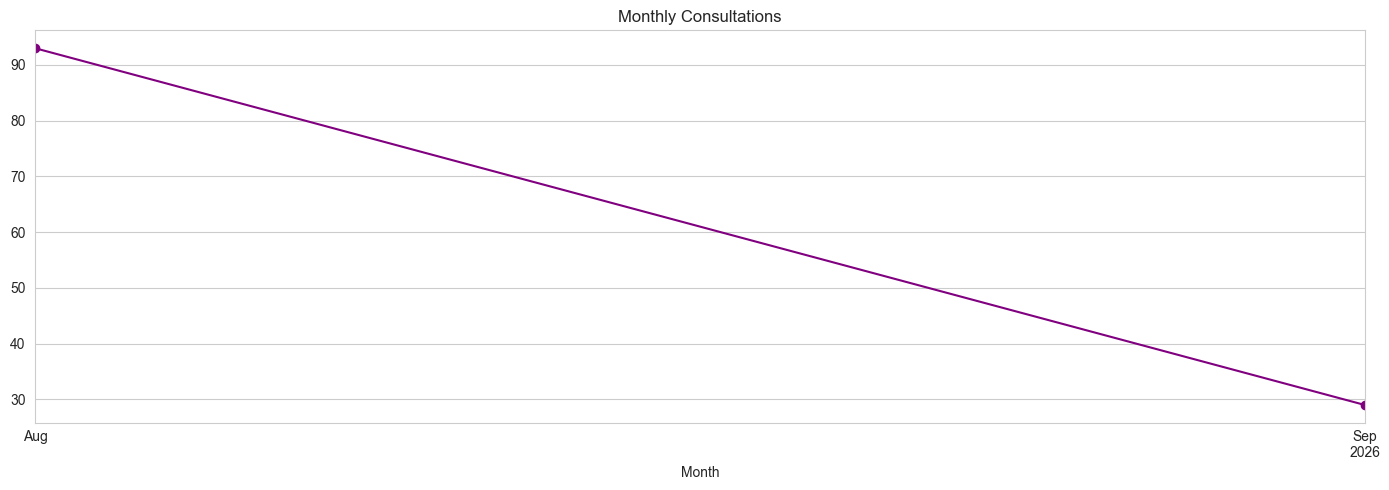

In [13]:
# Merge with patient for demographics
cons_p = consultations.merge(patient[['Id','Age','Gender','Age Group']],
                              left_on='Patient Id', right_on='Id',
                              suffixes=('','_pat'))

# Top diagnoses
top_diag = cons_p['Diagnosis'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_diag.index, x=top_diag.values, palette='magma')
plt.title('Top 15 Diagnoses')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Diagnosis by gender
if 'Gender' in cons_p.columns:
    top10 = top_diag.head(10).index
    subset = cons_p[cons_p['Diagnosis'].isin(top10)]
    ct = pd.crosstab(subset['Diagnosis'], subset['Gender'])
    ct.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='Set2')
    plt.title('Top 10 Diagnoses by Gender')
    plt.tight_layout()
    plt.show()

# Referrals breakdown
referrals = ['Refer To Pharmacy', 'Refer To Laboratory',
             'Refer To Optician', 'Refer To Specialist']
ref_counts = consultations[referrals].apply(lambda x: (x == True).sum()
                                             if x.dtype == bool
                                             else (x.astype(str).str.lower()=='true').sum())
plt.figure(figsize=(9, 5))
ref_counts.plot(kind='bar', color='mediumseagreen')
plt.title('Referral Distribution')
plt.ylabel('Number of Referrals')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Monthly consultation trend
consultations['Month'] = consultations['Created At'].dt.to_period('M')
consultations.groupby('Month').size().plot(figsize=(14,5), marker='o', color='purple')
plt.title('Monthly Consultations')
plt.tight_layout()
plt.show()

# Step 8: Lab Tests Analysis


--- Malaria Parasite ---
Malaria Parasite
PENDING     12
NEGATIVE    10
Name: count, dtype: int64

--- Random Blood Sugar ---
Random Blood Sugar
NaN      11
71.0      2
91.0      1
100.0     1
293.0     1
89.0      1
92.0      1
147.0     1
73.0      1
80.0      1
84.0      1
Name: count, dtype: int64

--- Hbsag ---
Hbsag
PENDING     12
NEGATIVE     9
POSITIVE     1
Name: count, dtype: int64


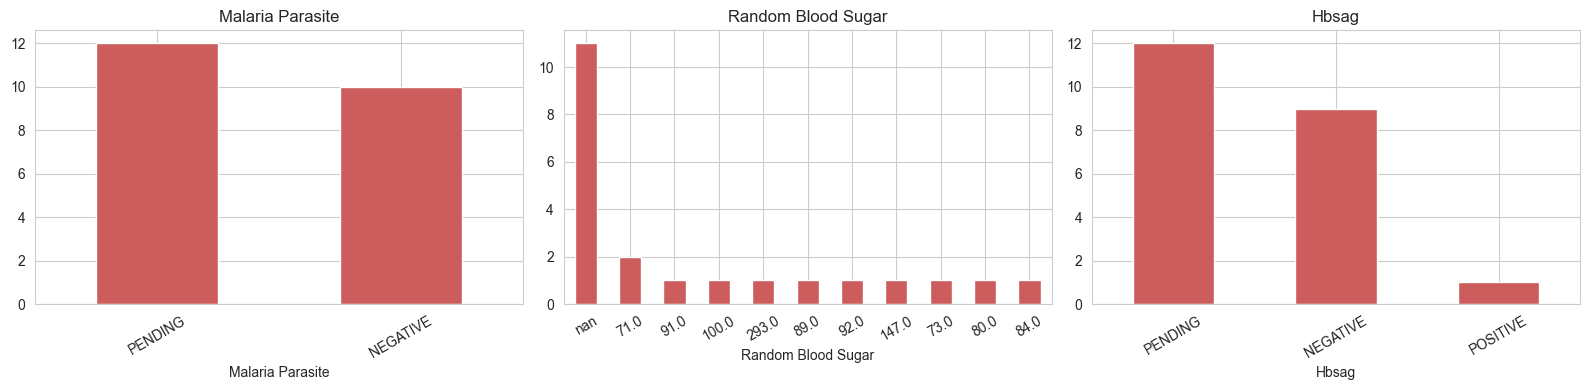


Lab TAT (hours) stats:
count    11.000000
mean      0.236176
std       0.188308
min       0.096986
25%       0.104744
50%       0.167728
75%       0.289673
max       0.601591
Name: TAT_hours, dtype: float64


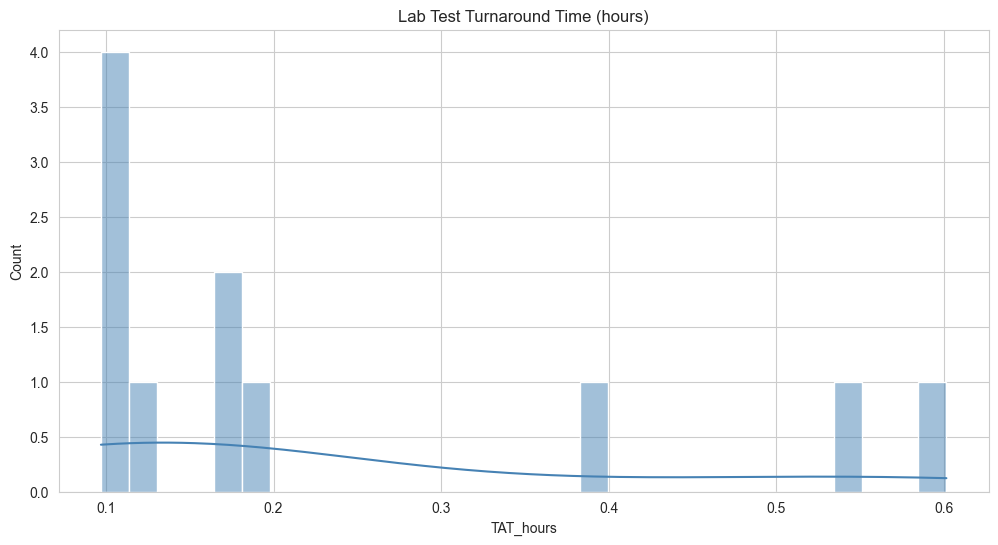

In [14]:
lab_cols = ['Malaria Parasite', 'Random Blood Sugar', 'Hbsag']

# Positive rates
for col in lab_cols:
    if col in lab_tests.columns:
        print(f"\n--- {col} ---")
        print(lab_tests[col].value_counts(dropna=False))

# Positive rate chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, lab_cols):
    lab_tests[col].value_counts(dropna=False).plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Lab test turnaround (Created -> Completed)
lab_tests['TAT_hours'] = (lab_tests['Completed At'] - lab_tests['Created At']).dt.total_seconds()/3600
print("\nLab TAT (hours) stats:")
print(lab_tests['TAT_hours'].describe())

sns.histplot(lab_tests['TAT_hours'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Lab Test Turnaround Time (hours)')
plt.show()

# Step 9: Optical Assessments

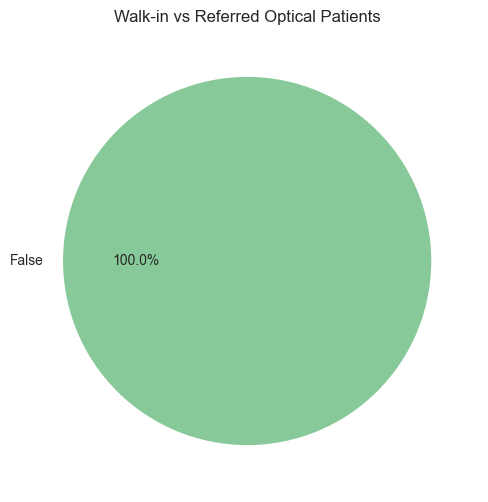

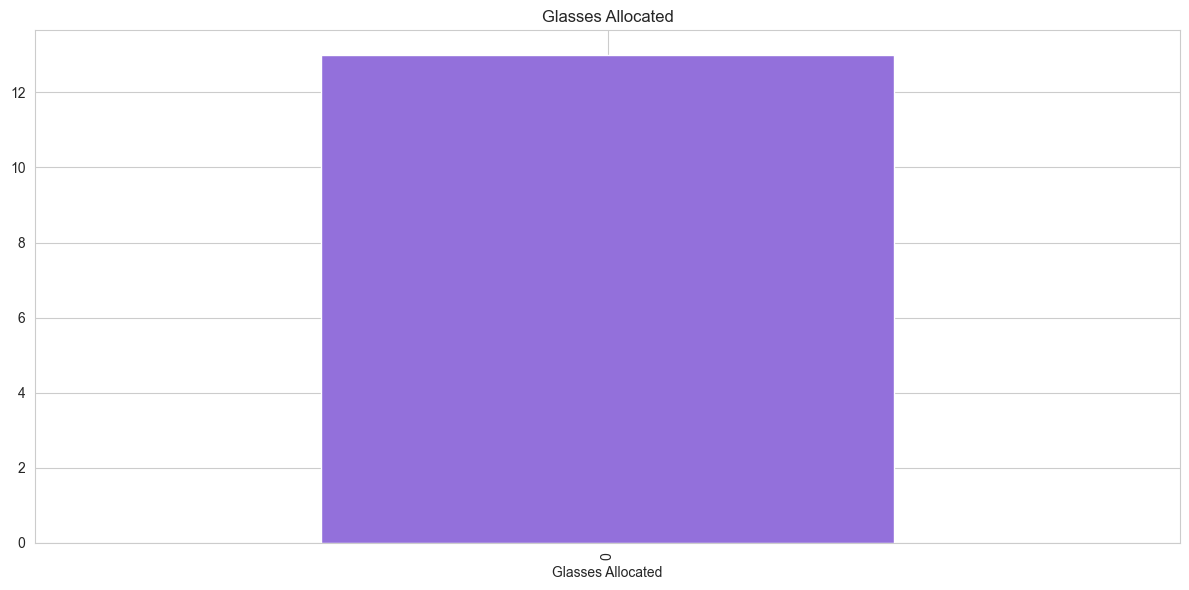

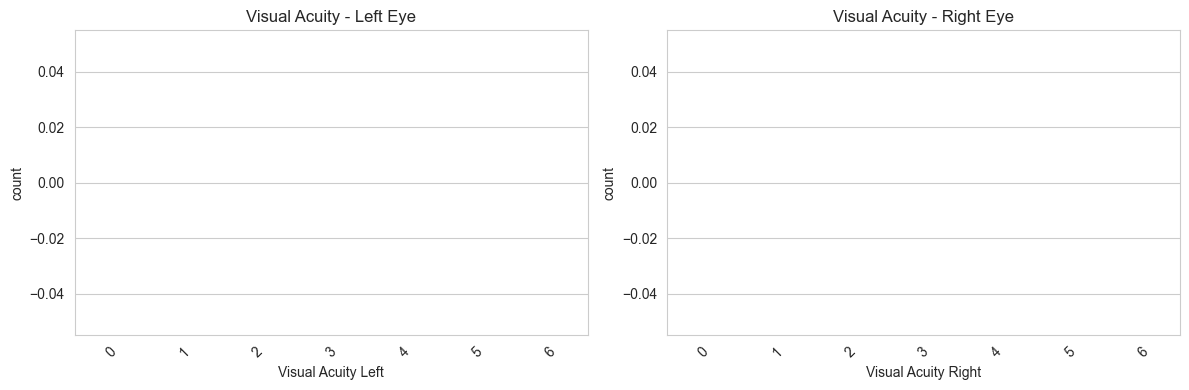

In [15]:
# Walk-in vs referred
optical['Is Walk In'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                          figsize=(6,6), colors=['#88c999','#f4a582'])
plt.title('Walk-in vs Referred Optical Patients')
plt.ylabel('')
plt.show()

# Glasses allocated
if 'Glasses Allocated' in optical.columns:
    optical['Glasses Allocated'].value_counts().plot(kind='bar', color='mediumpurple')
    plt.title('Glasses Allocated')
    plt.tight_layout()
    plt.show()

# Visual acuity distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=optical, x='Visual Acuity Left', ax=axes[0], palette='Blues')
axes[0].set_title('Visual Acuity - Left Eye')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=optical, x='Visual Acuity Right', ax=axes[1], palette='Greens')
axes[1].set_title('Visual Acuity - Right Eye')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Step 10: Pharmacy & Drugs Analysis

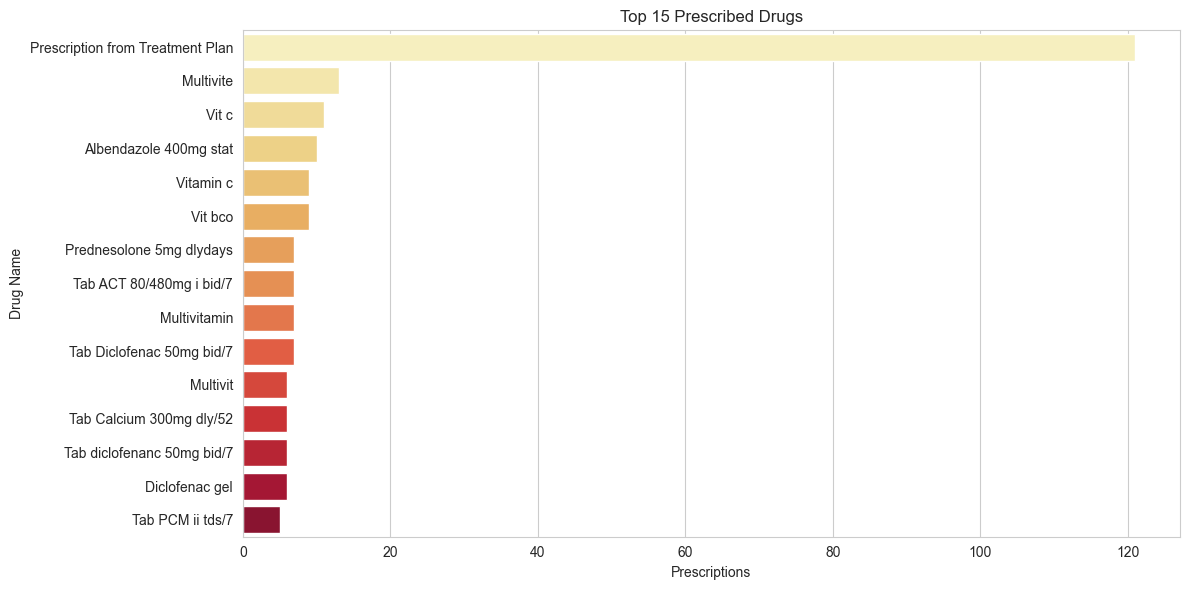

Dispensed status:
 Dispensed
True    577
Name: count, dtype: int64


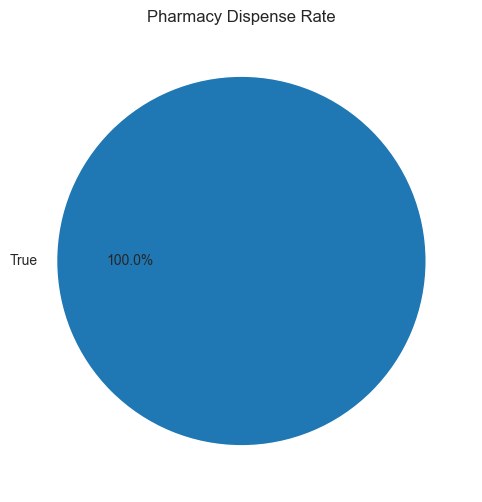

Stock Status
OK         42
Reorder    19
Name: count, dtype: int64


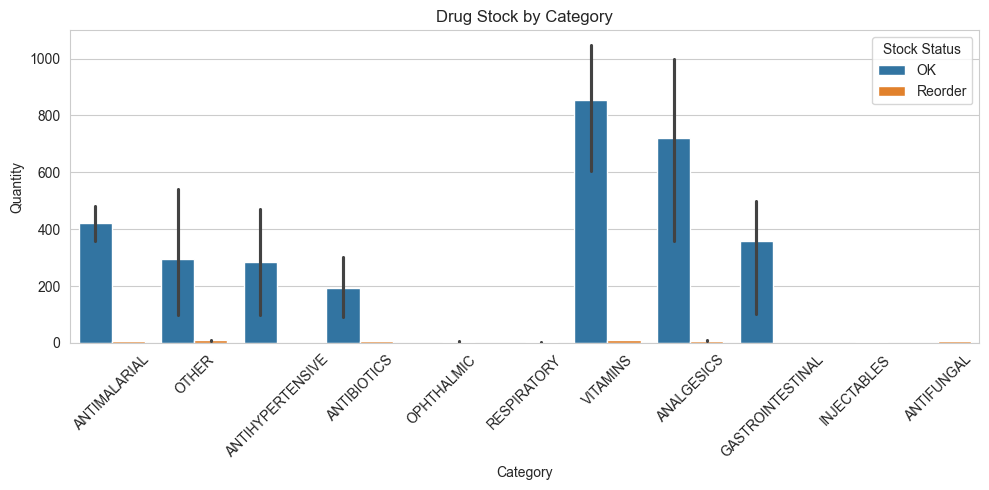


 Drugs needing reorder:
                              Name      Category  Quantity  Reorder Level
10             Antallerge eye drop    OPHTHALMIC         6             10
11       Artemether Injection 80mg  ANTIMALARIAL         6             10
14               Broncholyte syrup   RESPIRATORY         4             10
17        Chloramphenicol eye drop    OPHTHALMIC         2             10
19               Cough syrup adult   RESPIRATORY         1             10
20            Cough syrup children   RESPIRATORY         4             10
21       Diclofenac Injection 75mg    ANALGESICS        10             10
24                 Diclofenanc gel    ANALGESICS        10             10
28                    Flagyl syrup   ANTIBIOTICS         6             10
31            Gentamicine eye drop    OPHTHALMIC         4             10
34  Hydrocortisone Injection 100mg   INJECTABLES         4             10
37            Ibuprofen suspension    ANALGESICS         2             10
42           

In [16]:
# Top prescribed drugs
top_drugs = pharmacy['Drug Name'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_drugs.index, x=top_drugs.values, palette='YlOrRd')
plt.title('Top 15 Prescribed Drugs')
plt.xlabel('Prescriptions')
plt.tight_layout()
plt.show()

# Dispensed rate
disp = pharmacy['Dispensed'].value_counts()
print("Dispensed status:\n", disp)
disp.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Pharmacy Dispense Rate')
plt.ylabel('')
plt.show()

# Inventory: low stock alerts
drugs['Stock Status'] = np.where(drugs['Quantity'] <= drugs['Reorder Level'],
                                  'Reorder', 'OK')
print(drugs['Stock Status'].value_counts())

plt.figure(figsize=(10, 5))
sns.barplot(data=drugs, x='Category', y='Quantity', hue='Stock Status')
plt.title('Drug Stock by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Low stock list
low_stock = drugs[drugs['Quantity'] <= drugs['Reorder Level']]
print("\n Drugs needing reorder:")
print(low_stock[['Name','Category','Quantity','Reorder Level']])

# Step 11: End-to-End Patient Journey

# Step 11: End-to-End Patient Journey

Total patients: 189
Patients with consultation: 113
Patients with lab test: 11
Patients with optical: 12
Patients with pharmacy: 113


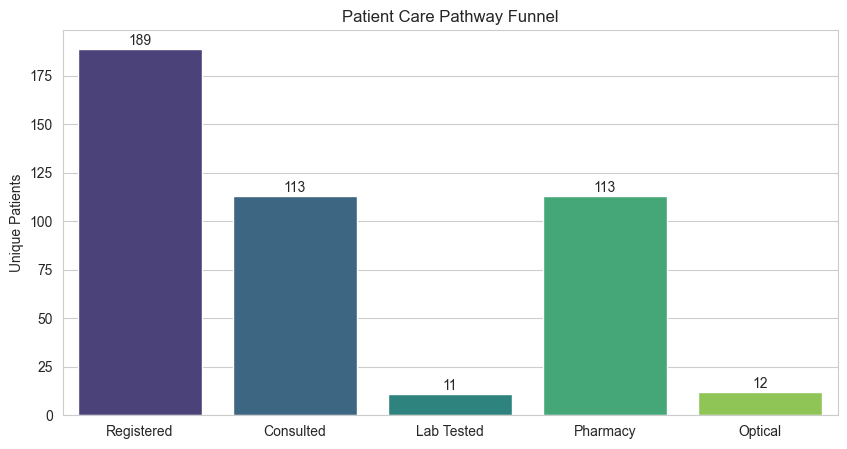

In [17]:
# Merge everything to see full workflow
journey = (patient
    .merge(consultations, left_on='Id', right_on='Patient Id',
           how='left', suffixes=('','_cons'))
    .merge(lab_tests, on='Patient Id', how='left', suffixes=('','_lab'))
    .merge(pharmacy, on='Patient Id', how='left', suffixes=('','_pharm'))
    .merge(optical, on='Patient Id', how='left', suffixes=('','_opt')))

print(f"Total patients: {patient['Id'].nunique()}")
print(f"Patients with consultation: {consultations['Patient Id'].nunique()}")
print(f"Patients with lab test: {lab_tests['Patient Id'].nunique()}")
print(f"Patients with optical: {optical['Patient Id'].nunique()}")
print(f"Patients with pharmacy: {pharmacy['Patient Id'].nunique()}")

# Funnel visualization
stages = ['Registered', 'Consulted', 'Lab Tested', 'Pharmacy', 'Optical']
counts = [
    patient['Id'].nunique(),
    consultations['Patient Id'].nunique(),
    lab_tests['Patient Id'].nunique(),
    pharmacy['Patient Id'].nunique(),
    optical['Patient Id'].nunique()
]
plt.figure(figsize=(10, 5))
sns.barplot(x=stages, y=counts, palette='viridis')
plt.title('Patient Care Pathway Funnel')
plt.ylabel('Unique Patients')
for i, v in enumerate(counts):
    plt.text(i, v+2, str(v), ha='center')
plt.show()

# Step 12: Advanced Insights

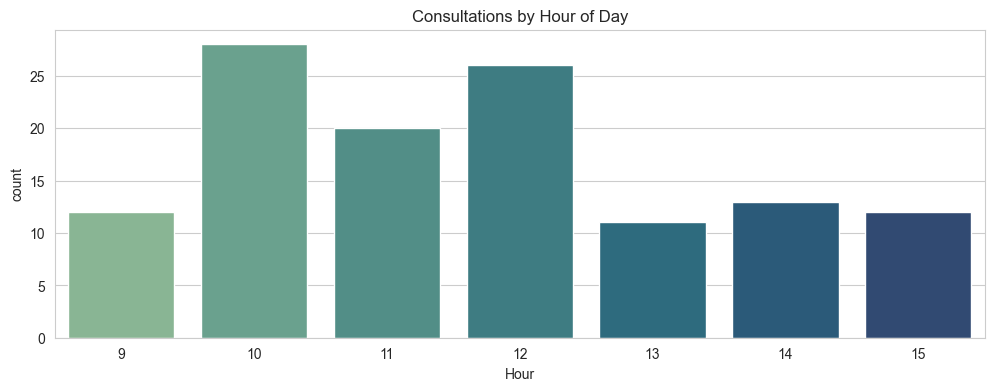

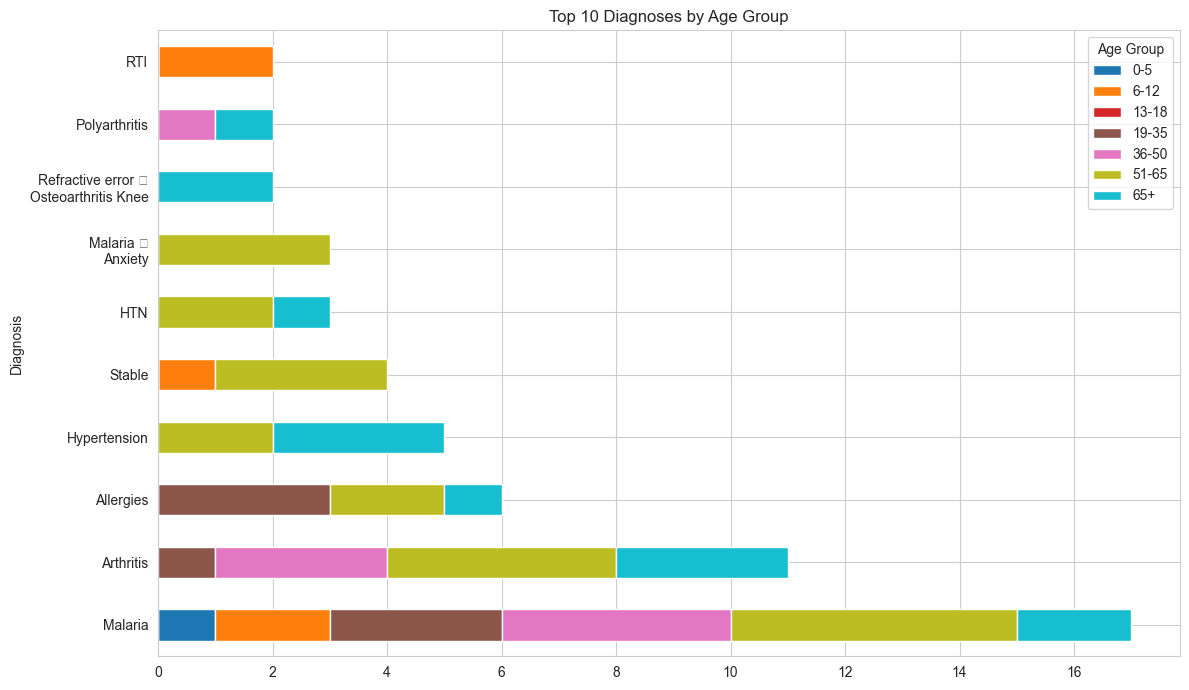

Repeat visit distribution:
1    105
2      7
3      1
Name: count, dtype: int64


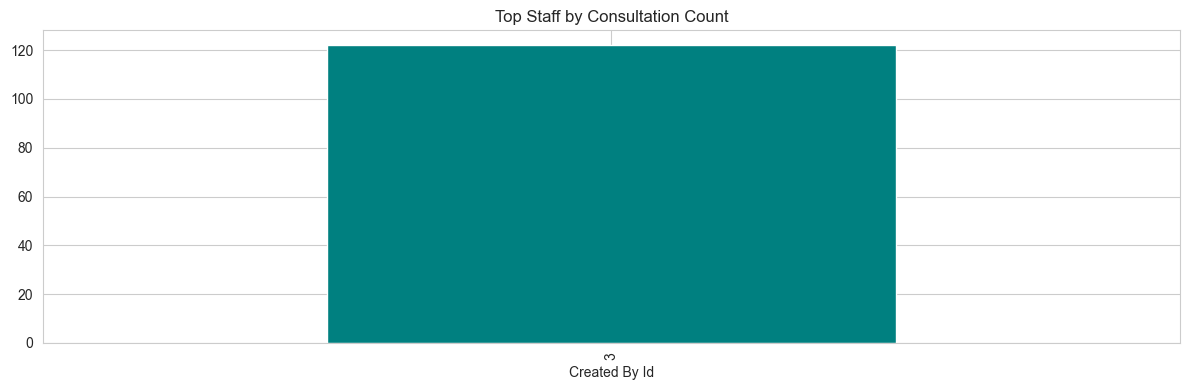

In [18]:
# 1. Time-of-day activity
consultations['Hour'] = consultations['Created At'].dt.hour
plt.figure(figsize=(12, 4))
sns.countplot(data=consultations, x='Hour', palette='crest')
plt.title('Consultations by Hour of Day')
plt.show()

# 2. Diagnoses by age group
top_diag_by_age = pd.crosstab(cons_p['Diagnosis'], cons_p['Age Group'])
top10 = cons_p['Diagnosis'].value_counts().head(10).index
top_diag_by_age.loc[top10].plot(kind='barh', stacked=True,
                                 figsize=(12, 7), colormap='tab10')
plt.title('Top 10 Diagnoses by Age Group')
plt.tight_layout()
plt.show()

# 3. Repeat visitors
visit_counts = consultations.groupby('Patient Id').size()
print("Repeat visit distribution:")
print(visit_counts.value_counts().sort_index().head(10))

# 4. Staff workload
staff_activity = consultations.groupby('Created By Id').size().sort_values(ascending=False)
plt.figure(figsize=(12, 4))
staff_activity.head(15).plot(kind='bar', color='teal')
plt.title('Top Staff by Consultation Count')
plt.tight_layout()
plt.show()

# Step 13: Export Summary Report

In [19]:
# Build an Excel summary
with pd.ExcelWriter('analysis_summary.xlsx') as writer:
    patient.describe(include='all').to_excel(writer, sheet_name='Patient_Summary')
    nursing[vitals].describe().to_excel(writer, sheet_name='Vitals_Summary')
    consultations['Diagnosis'].value_counts().to_excel(writer, sheet_name='Diagnoses')
    pharmacy['Drug Name'].value_counts().to_excel(writer, sheet_name='Drugs_Prescribed')
    low_stock.to_excel(writer, sheet_name='Low_Stock', index=False)

print("Summary exported to analysis_summary.xlsx")

Summary exported to analysis_summary.xlsx
